# FIP 06 — Splitting trials for RPE slopes: by RPE sign or by outcome

Rachel's RPE slope (`rachel_analysis_utils.analysis_utils.add_AUC_and_rpe_slope`) fits one line to
trials with `RPE_earned ≥ 0` and one to trials with `RPE_earned < 0`. The response is the mean
`data_z_norm` 0.33–1 s after the choice. The alternative is to split by outcome, rewarded vs
unrewarded. The two splits differ only for trials with RPE exactly 0. This notebook asks:

1. Which trials have RPE exactly 0, and why?
2. Does moving them change the slopes? First one session in Rachel's plot layout, then every
   session.
3. Which group do their signals resemble, rewarded or unrewarded?

Everything uses Rachel's code and the columns her pipeline stored: `dummy_nwb.load` for loading,
`get_RPE_by_avg_signal_fit` for slopes, the stored `avg_data_z_norm_<channel>_choice_time` column
for the response, and `alignment.event_triggered_response` for traces. The two assets are the
CSV-curated builds of `DANE_3channels_curated` and the 4-channel rebuild.

**Environment.** `.venv-fip` (Python 3.12), with `rachel-analysis-utils@864550d` (the Dockerfile
pin), `aind-dynamic-foraging-data-utils@32e8dbe` and `aind-dynamic-foraging-basic-analysis@8ec194f`.

In [1]:
import contextlib
import glob
import io
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from rachel_analysis_utils.nwb_utils import dummy_nwb
from rachel_analysis_utils.analysis_utils import get_RPE_by_avg_signal_fit
from aind_dynamic_foraging_data_utils import alignment
from plotstyle import apply_style, style_ax, save_fig, PALETTE, OKABE_ITO

apply_style()
IS_CO = os.path.isdir("/root/capsule")
ASSET_ROOTS = (["/root/capsule/data/DANE_3channels_curated",
                "/root/capsule/data/DANE_4channels_curated/data"] if IS_CO else
               ["../../data/results-a278f830-9bf2-48e8-9928-a2ff78e4818f",
                "../../data/results-ddcccb0f-f18f-44a6-a2b1-caba680d28a1/data"])
FIG_DIR = "/root/capsule/scratch/figures/fip" if IS_CO else "../data/figures/fip"
SAVE_FIG = True

EXAMPLE_SESSION, EXAMPLE_CHANNEL = "809491_2025-10-30", "latNAcc(L)-DA"
WINDOW = (0.33, 1.0)   # Rachel's add_AUC_and_rpe_slope default, s after the choice
C_REW, C_UNREW, C_ZERO = PALETTE["pos"], PALETTE["neg"], OKABE_ITO["orange"]

## 1. Which trials have RPE exactly 0?

`RPE_earned = earned_reward − Q_chosen`, with Q in [0, 1]. RPE is exactly 0 when:

- an **unrewarded** trial has Q_chosen = 0. Rachel's split puts it in the RPE ≥ 0 group with the
  rewards;
- a **rewarded** trial has Q_chosen = 1. Both splits already put it with the rewards, so it
  cannot change anything, but it is counted here to check that it does not occur.

In [2]:
def load_all_trials(roots):
    '''df_trials of every session, via Rachel's dummy_nwb.load, plus each session's fit parameters.'''
    frames = []
    for root in roots:
        sess = pd.concat([pd.read_csv(f) for f in glob.glob(f"{root}/df_sess_*.csv")])
        for folder in sorted(glob.glob(f"{root}/*/*/")):
            t = dummy_nwb.load(folder, load_fip=False).df_trials
            frames.append(t.merge(sess[["ses_idx", "learn_rate", "forget_rate_unchosen"]],
                                  on="ses_idx", how="left"))
    t = pd.concat(frames, ignore_index=True)
    t["subject"] = t["ses_idx"].str.split("_").str[0]
    return t

trials = load_all_trials(ASSET_ROOTS)
resp = trials[trials["animal_response"] < 2].dropna(subset=["RPE_earned"]).copy()
rew = resp["earned_reward"].astype(bool)
resp["group"] = np.select([rew, resp["RPE_earned"] == 0], ["rewarded", "unrewarded, RPE = 0"],
                          "unrewarded, RPE < 0")

zero_unrew = ~rew & (resp["RPE_earned"] == 0)
# True until the session's first rewarded trial: Q is still the model's initial value of 0 there
first_rewarded = resp.assign(r=rew).groupby("ses_idx")["r"].transform(lambda r: r.cumsum().shift(fill_value=0) == 0)
resp["before_first_reward"] = first_rewarded
resp["zero_origin"] = np.select([zero_unrew & first_rewarded,
                                 zero_unrew & (resp.forget_rate_unchosen >= 0.999)],
                                ["session start", "forget = 1"], np.where(zero_unrew, "other", ""))
print(f"{len(resp)} responded trials, {resp.ses_idx.nunique()} sessions, {resp.subject.nunique()} animals")
print(f"unrewarded, Q_chosen = 0 (RPE = 0): {zero_unrew.sum()} ({zero_unrew.mean():.1%})")
print(f"rewarded,   Q_chosen = 1 (RPE = 0): {(rew & (resp.RPE_earned == 0)).sum()}; "
      f"max Q_chosen = {resp.Q_chosen.max():.12f}")
print("\nwhere the unrewarded RPE = 0 trials come from:")
print(f"  sessions with forget_rate_unchosen fit at 1.0 (unchosen Q reset to 0 each trial): "
      f"{(zero_unrew & (resp.forget_rate_unchosen >= 0.999)).sum()}")
print(f"  other sessions, before the first reward of the session (Q still at its initial 0): "
      f"{(zero_unrew & (resp.forget_rate_unchosen < 0.999) & first_rewarded).sum()}")
print(f"  other sessions, after a reward: "
      f"{(zero_unrew & (resp.forget_rate_unchosen < 0.999) & ~first_rewarded).sum()}")

135919 responded trials, 301 sessions, 15 animals
unrewarded, Q_chosen = 0 (RPE = 0): 1400 (1.0%)
rewarded,   Q_chosen = 1 (RPE = 0): 0; max Q_chosen = 0.999999999975

where the unrewarded RPE = 0 trials come from:
  sessions with forget_rate_unchosen fit at 1.0 (unchosen Q reset to 0 each trial): 854
  other sessions, before the first reward of the session (Q still at its initial 0): 465
  other sessions, after a reward: 81


## 2. One session, Rachel's plot, both splits

Panel a is Rachel's RPE-slope plot for the example session, recomputed with her function. Panel b
refits the same points split by outcome. The RPE = 0 omissions are in orange. The check line
compares panel a with the `rpe_slope.csv` her pipeline saved.

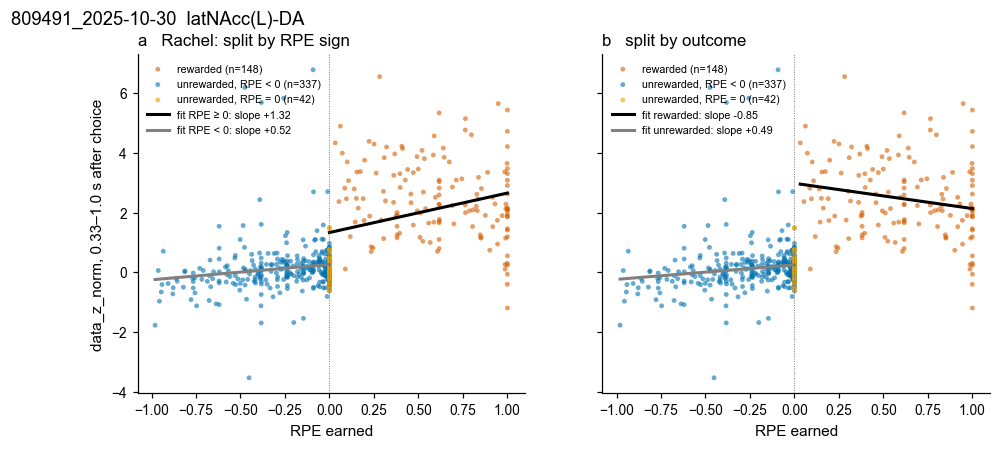

In [3]:
folder = next(f for r in ASSET_ROOTS for f in glob.glob(f"{r}/*/{EXAMPLE_SESSION}"))
ex = dummy_nwb.load(folder, load_fip=True)
col = f"avg_data_z_norm_{EXAMPLE_CHANNEL}_choice_time"
x = ex.df_trials.dropna(subset=[col, "RPE_earned"]).copy()
x_rew = x["earned_reward"].astype(bool)
x["group"] = np.select([x_rew, x["RPE_earned"] == 0], ["rewarded", "unrewarded, RPE = 0"],
                       "unrewarded, RPE < 0")

splits = {
    "a   Rachel: split by RPE sign": {"RPE ≥ 0": x[x.RPE_earned >= 0], "RPE < 0": x[x.RPE_earned < 0]},
    "b   split by outcome": {"rewarded": x[x_rew], "unrewarded": x[~x_rew]},
}
saved = glob.glob(f"{os.path.dirname(os.path.dirname(folder))}/rpe_slope.csv")
if saved:
    s = pd.read_csv(saved[0])
    s = s[(s.date == EXAMPLE_SESSION.split("_")[1]) & s.channel.str.startswith(EXAMPLE_CHANNEL)]
    print("rpe_slope.csv:", s[["slope (RPE >= 0)", "slope (RPE < 0)"]].round(3).to_dict("records"))

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, (title, parts) in zip(axes, splits.items()):
    for g, c in (("rewarded", C_REW), ("unrewarded, RPE < 0", C_UNREW), ("unrewarded, RPE = 0", C_ZERO)):
        h = x[x.group == g]
        ax.scatter(h.RPE_earned, h[col], s=10, color=c, alpha=0.6, edgecolor="none",
                   label=f"{g} (n={len(h)})")
    for (name, d), c in zip(parts.items(), ("k", "0.5")):
        xf, yf, slope = get_RPE_by_avg_signal_fit(d, col)
        ax.plot(xf, yf, color=c, lw=2, label=f"fit {name}: slope {slope:+.2f}")
    ax.axvline(0, color=PALETTE["neutral"], lw=0.6, ls=":")
    ax.set_xlabel("RPE earned")
    ax.set_title(title, loc="left")
    ax.legend(fontsize=7, loc="upper left")
    style_ax(ax)
axes[0].set_ylabel(f"data_z_norm, {WINDOW[0]}–{WINDOW[1]} s after choice")
fig.suptitle(f"{EXAMPLE_SESSION}  {EXAMPLE_CHANNEL}", x=0.01, ha="left")
save_fig(fig, "fip_06_example_split", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 3. Do RPE = 0 omissions look like rewards or omissions?

If the RPE = 0 omissions belong with the rewards, their response should sit with the rewarded
trials. The fair comparison is with the rewarded trials of *lowest* RPE (most expected rewards,
RPE < 0.25), since RPE = 0 is the low end of the rewarded range. First the example session's
traces (Rachel's `event_triggered_response` on `data_z_norm`, aligned to the choice), then the
stored window value, averaged per animal, for every DA and NE channel, with the RPE = 0
omissions split by origin (section 1).

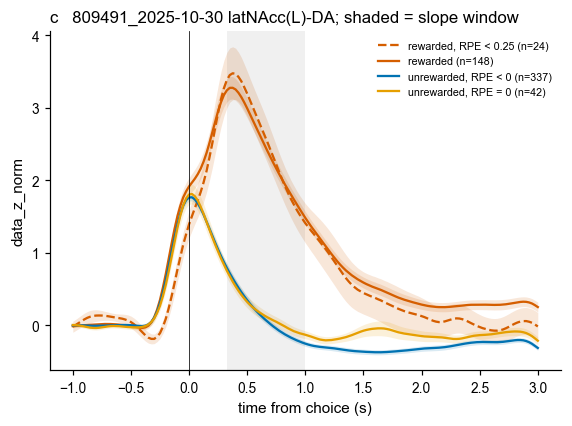

In [4]:
fip = ex.df_fip[ex.df_fip.event == EXAMPLE_CHANNEL]
groups = {"rewarded, RPE < 0.25": (x_rew & (x.RPE_earned < 0.25), OKABE_ITO["vermillion"], "--"),
          "rewarded": (x_rew, C_REW, "-"),
          "unrewarded, RPE < 0": (x.group == "unrewarded, RPE < 0", C_UNREW, "-"),
          "unrewarded, RPE = 0": (x.group == "unrewarded, RPE = 0", C_ZERO, "-")}
fig, ax = plt.subplots(figsize=(6, 4))
for name, (m, c, ls) in groups.items():
    etr = alignment.event_triggered_response(fip, "timestamps", "data_z_norm",
                                             x.loc[m, "choice_time_in_session"].values,
                                             t_start=-1, t_end=3, output_sampling_rate=40)
    g = etr.groupby("time")["data_z_norm"]
    mu, se = g.mean(), g.sem()
    ax.plot(mu.index, mu, color=c, ls=ls, label=f"{name} (n={m.sum()})")
    ax.fill_between(mu.index, mu - se, mu + se, color=c, alpha=0.15, lw=0)
ax.axvspan(*WINDOW, color="k", alpha=0.06, lw=0)
ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel("time from choice (s)")
ax.set_ylabel("data_z_norm")
ax.set_title(f"c   {EXAMPLE_SESSION} {EXAMPLE_CHANNEL}; shaded = slope window", loc="left")
ax.legend(fontsize=7)
style_ax(ax)
save_fig(fig, "fip_06_example_traces", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

DA, RPE = 0, forget = 1     : closer to unrewarded in 10/10 animals; median position between unrewarded (0) and low-RPE rewarded (1) = 0.04
DA, RPE = 0, session start  : closer to unrewarded in 4/15 animals; median position between unrewarded (0) and low-RPE rewarded (1) = 0.60
NE, RPE = 0, forget = 1     : closer to unrewarded in 6/6 animals; median position between unrewarded (0) and low-RPE rewarded (1) = -0.36
NE, RPE = 0, session start  : closer to unrewarded in 3/11 animals; median position between unrewarded (0) and low-RPE rewarded (1) = 0.66


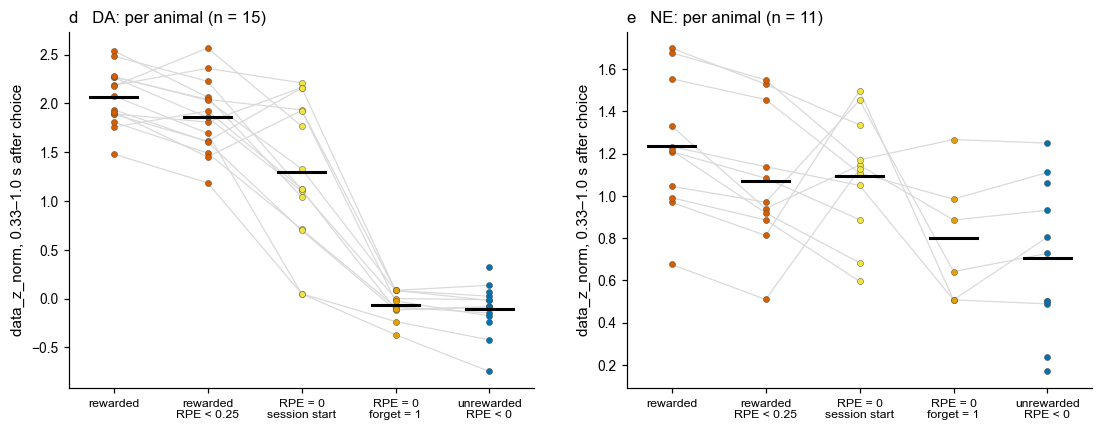

In [5]:
def channel_cols(df):
    '''Stored window columns for lateral-NAc DA and PL NE, keyed by signal type.'''
    out = {}
    for c in df.columns:
        if c.startswith("avg_data_z_norm_") and c.endswith("_choice_time"):
            if "latNAcc" in c and "-DA" in c:
                out.setdefault("DA", []).append(c)
            elif "LCAxonCa" in c:
                out.setdefault("NE", []).append(c)
    return out

resp["cls"] = np.select(
    [resp.zero_origin == "forget = 1", resp.zero_origin == "session start",
     resp.group.eq("rewarded") & (resp.RPE_earned < 0.25), resp.group.eq("rewarded"),
     resp.group.eq("unrewarded, RPE < 0")],
    ["RPE = 0, forget = 1", "RPE = 0, session start", "rewarded, RPE < 0.25", "rewarded",
     "unrewarded, RPE < 0"], "")
level = []
for sig, cols in channel_cols(resp).items():
    for c in cols:
        d = resp.dropna(subset=[c])
        m = pd.concat([d[d.cls != ""].groupby(["subject", "ses_idx", "cls"])[c].mean(),
                       d[d.group == "rewarded"].assign(cls="rewarded")
                       .groupby(["subject", "ses_idx", "cls"])[c].mean()])
        level.append(m.rename("value").reset_index().assign(sig=sig, channel=c))
level = pd.concat(level).drop_duplicates(["sig", "subject", "ses_idx", "cls", "channel"])
animal = level.groupby(["sig", "subject", "cls"])["value"].mean().unstack("cls")
ORDER = ["rewarded", "rewarded, RPE < 0.25", "RPE = 0, session start", "RPE = 0, forget = 1",
         "unrewarded, RPE < 0"]
animal = animal[ORDER]

for sig, a in animal.groupby(level="sig"):
    for z in ("RPE = 0, forget = 1", "RPE = 0, session start"):
        b = a[[z, "rewarded, RPE < 0.25", "unrewarded, RPE < 0"]].dropna()
        frac = (b[z] - b["unrewarded, RPE < 0"]) / (b["rewarded, RPE < 0.25"] - b["unrewarded, RPE < 0"])
        closer = ((b[z] - b["unrewarded, RPE < 0"]).abs() < (b[z] - b["rewarded, RPE < 0.25"]).abs()).sum()
        print(f"{sig}, {z:24s}: closer to unrewarded in {closer}/{len(b)} animals; "
              f"median position between unrewarded (0) and low-RPE rewarded (1) = {frac.median():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
cols_c = [C_REW, OKABE_ITO["vermillion"], OKABE_ITO["yellow"], C_ZERO, C_UNREW]
for ax, (sig, a) in zip(axes, animal.groupby(level="sig")):
    for _, r in a.iterrows():
        ax.plot(range(len(ORDER)), r.values, color="0.85", lw=0.8, zorder=1)
    for k, g in enumerate(ORDER):
        ax.scatter(np.full(len(a), k), a[g], color=cols_c[k], s=16, zorder=2, edgecolor="0.3", lw=0.3)
        ax.plot([k - 0.25, k + 0.25], [a[g].mean()] * 2, color="k", lw=2, zorder=3)
    ax.set_xticks(range(len(ORDER)))
    ax.set_xticklabels(["rewarded", "rewarded\nRPE < 0.25", "RPE = 0\nsession start",
                        "RPE = 0\nforget = 1", "unrewarded\nRPE < 0"], fontsize=8)
    ax.set_ylabel(f"data_z_norm, {WINDOW[0]}–{WINDOW[1]} s after choice")
    ax.set_title(f"{'de'[sig == 'NE']}   {sig}: per animal (n = {len(a)})", loc="left")
    style_ax(ax)
save_fig(fig, "fip_06_rpe0_similarity", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 4. The effect on slopes in every session

Three options, each fit with `get_RPE_by_avg_signal_fit` for every session and channel and
averaged within animal: Rachel's split, the outcome split, and the outcome split without trials
before the session's first reward, where Q is still the model's starting value. Sessions without
RPE = 0 omissions give identical slopes under all three, which dilutes the difference; they stay
in, as they would in a pooled analysis.

In [6]:
rows = []
for sig, cols in channel_cols(resp).items():
    for c in cols:
        for ses, d in resp.dropna(subset=[c]).groupby("ses_idx"):
            r_ = d.earned_reward.astype(bool)
            late = ~d.before_first_reward
            fits = {"rachel_pos": d[d.RPE_earned >= 0], "outcome_rew": d[r_],
                    "outcome_rew_nostart": d[r_ & late],
                    "rachel_neg": d[d.RPE_earned < 0], "outcome_unrew": d[~r_],
                    "outcome_unrew_nostart": d[~r_ & late]}
            row = dict(sig=sig, subject=d.subject.iloc[0], ses_idx=ses, channel=c,
                       n_zero=int((~r_ & (d.RPE_earned == 0)).sum()),
                       rew_rpe_sd=d.loc[r_, "RPE_earned"].std())
            for k, dd in fits.items():
                row[k] = get_RPE_by_avg_signal_fit(dd, c)[2] if len(dd) > 2 else np.nan
            rows.append(row)
slopes = pd.DataFrame(rows)
SLOPE_COLS = ["rachel_pos", "outcome_rew", "outcome_rew_nostart",
              "rachel_neg", "outcome_unrew", "outcome_unrew_nostart"]
sl_animal = slopes.groupby(["sig", "subject"])[SLOPE_COLS].mean()

summary = []
for sig, a in sl_animal.groupby(level="sig"):
    for cols_, lab in ((SLOPE_COLS[:3], "reward side"), (SLOPE_COLS[3:], "omission side")):
        for col_ in cols_:
            summary.append(dict(signal=sig, side=lab, split=col_, mean_slope=a[col_].mean(),
                                median_slope=a[col_].median(),
                                n_positive=f"{(a[col_] > 0).sum()}/{len(a)}",
                                p_vs_0=stats.wilcoxon(a[col_]).pvalue))
per_session = slopes.assign(diff=slopes.rachel_pos - slopes.outcome_rew)
narrow = per_session[(per_session.rew_rpe_sd < 0.05) & (per_session.n_zero > 0)]
print(f"session-channels whose rewarded RPEs span a narrow range (sd < 0.05) and that have RPE = 0 "
      f"omissions: {len(narrow)}; their reward-side slope under Rachel's split is set mostly by the "
      f"RPE = 0 points, e.g.")
print(narrow.sort_values("diff", key=abs, ascending=False)
      [["ses_idx", "channel", "n_zero", "rew_rpe_sd", "rachel_pos", "outcome_rew"]].head(3).round(3).to_string(index=False))
print("reward-side slope change (Rachel − outcome) in sessions with ≥ 10 RPE = 0 omissions: "
      f"median {per_session[per_session.n_zero >= 10]['diff'].median():+.2f} "
      f"(n = {(per_session.n_zero >= 10).sum()} session-channels)")
pd.DataFrame(summary).set_index(["signal", "side", "split"]).round(3)

session-channels whose rewarded RPEs span a narrow range (sd < 0.05) and that have RPE = 0 omissions: 6; their reward-side slope under Rachel's split is set mostly by the RPE = 0 points, e.g.
          ses_idx                                   channel  n_zero  rew_rpe_sd  rachel_pos  outcome_rew
818580_2025-11-11 avg_data_z_norm_latNAcc(R)-DA_choice_time      33       0.023       2.601      -20.481
818580_2025-11-11 avg_data_z_norm_latNAcc(L)-DA_choice_time      33       0.023       2.616      -17.427
815334_2025-10-31 avg_data_z_norm_latNAcc(L)-DA_choice_time       3       0.031       1.470       -2.296
reward-side slope change (Rachel − outcome) in sessions with ≥ 10 RPE = 0 omissions: median +0.59 (n = 78 session-channels)


mean_slope  median_slope  \
signal side          split                                             
DA     reward side   rachel_pos                  0.361         0.494   
                     outcome_rew                 0.149         0.215   
                     outcome_rew_nostart         0.173         0.225   
       omission side rachel_neg                  0.379         0.380   
                     outcome_unrew               0.403         0.423   
                     outcome_unrew_nostart       0.373         0.371   
NE     reward side   rachel_pos                  0.279         0.279   
                     outcome_rew                 0.305         0.293   
                     outcome_rew_nostart         0.308         0.299   
       omission side rachel_neg                  0.119         0.173   
                     outcome_unrew               0.134         0.190   
                     outcome_unrew_nostart       0.118         0.176   

                                           n_positive  p_vs_0  
signal side          split                                     
DA     reward side   rachel_pos                 10/15   0.083  
                     outcome_rew                 9/15   0.489  
                     outcome_rew_nostart         9/15   0.359  
       omission side rachel_neg                 14/15   0.000  
                     outcome_unrew              14/15   0.000  
                     outcome_unrew_nostart      14/15   0.000  
NE     reward side   rachel_pos                 11/11   0.001  
                     outcome_rew                11/11   0.001  
                     outcome_rew_nostart        11/11   0.001  
       omission side rachel_neg                  8/11   0.206  
                     outcome_unrew               8/11   0.206  
                     outcome_unrew_nostart       8/11   0.206

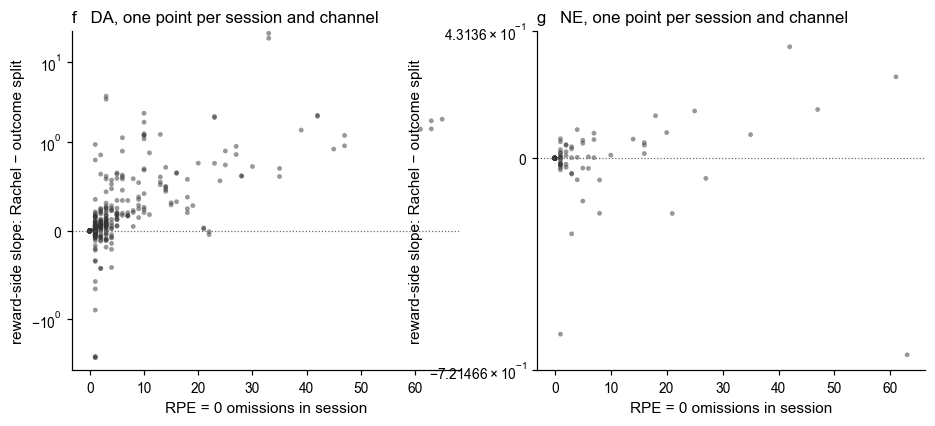

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (sig, g) in zip(axes, per_session.groupby("sig")):
    ax.scatter(g.n_zero, g["diff"], s=10, color=PALETTE["all"], alpha=0.5, edgecolor="none")
    ax.axhline(0, color=PALETTE["neutral"], lw=0.8, ls=":")
    ax.set_yscale("symlog", linthresh=1)
    ax.set_xlabel("RPE = 0 omissions in session")
    ax.set_ylabel("reward-side slope: Rachel − outcome split")
    ax.set_title(f"{'fg'[sig == 'NE']}   {sig}, one point per session and channel", loc="left")
    style_ax(ax)
save_fig(fig, "fip_06_slope_change", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## Summary

- **Only unrewarded trials with Q_chosen = 0 differ between the splits.** There are 1,400 (1.0% of
  responded trials). No rewarded trial has Q_chosen = 1 (maximum 0.999999999975), so the opposite
  case does not occur: every rewarded trial has RPE > 0 and both splits put it with the rewards.
- **They come from two places.** 854 are in the 37 sessions where the model's
  `forget_rate_unchosen` was fit at its bound of 1.0, which resets the unchosen side's Q to 0 on
  every trial, so an unrewarded switch has Q_chosen = 0. 465 come before the session's first
  reward, when Q is still at its initial 0. 81 are other cases.
- **Moving them changes the reward-side slope.** In the example session, 42 of them turn the
  reward-side slope from −0.85 (rewarded trials only) to +1.32 (Rachel's split). Across sessions
  with ≥ 10 of them, the median shift is +0.59. Pooled over 15 animals, DA's reward-side slope
  drops from +0.36 to +0.15 (medians +0.49 and +0.22) and was not significant under either
  split. NE's slopes barely move, because NE's response to an omission is close to its response
  to a reward in this window.
- **The forget = 1 trials look like omissions.** They sit at the unrewarded level in 10/10
  animals for DA and 6/6 for NE (median position 0.04 of the way from unrewarded to low-RPE
  rewarded). Including them with the rewards puts omission-sized responses at the low end of the
  reward line. When rewarded RPEs span a narrow range, as in 818580_2025-11-11 (RPE 0.90–1.00),
  those points alone set the slope, which then measures the reward-vs-omission difference, not
  RPE scaling.
- **The session-start trials resemble neither group.** DA is elevated (median 0.60 of the way
  toward low-RPE rewards) with no water delivered. Their Q is the model's starting value, not an
  estimate of the animal's expectation, so they have no meaningful RPE under either split.

**Recommendation.** Split by outcome (rewarded vs unrewarded), and leave out trials before the
session's first reward. In the pooled slopes this changes DA's reward side and leaves NE and both
omission sides essentially unchanged.